# Cotton Plant Disease Detection with Transfer Learning

### Import Required Libraries and Modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import shuffle
from skimage.transform import resize
from glob import glob
from sklearn.model_selection import train_test_split
import tensorflow_hub as hub
import tensorflow as tf
from tensorflow.keras import applications, Sequential, layers
#from tensorflow.keras.models import Sequential
#from tensorflow.keras import layers
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings("ignore")

### Collect Image Paths for Each Category 

In [2]:
aphids = glob('Cotton plant_diseases/Aphids/*.jpg')
army_worm = glob('Cotton plant_diseases/Army worm/*.jpg')
bacterial_blight = glob('Cotton plant_diseases/Bacterial Blight/*.jpg')
healthy = glob('Cotton plant_diseases/Healthy/*.jpg')
powdery_mildew = glob('Cotton plant_diseases/Powdery Mildew/*.jpg')
target_spot = glob('Cotton plant_diseases/Target spot/*.jpg')

In [3]:
print("Number of images in each classes are\nAphids:",len(aphids),"\nArmy Worm:",len(army_worm),
      "\nBacterial Blight:",len(bacterial_blight),"\nHealthy:",len(healthy),"\nPowdery Mildew",len(powdery_mildew),"\nTarget Spot",len(target_spot))

Number of images in each classes are
Aphids: 400 
Army Worm: 400 
Bacterial Blight: 400 
Healthy: 390 
Powdery Mildew 400 
Target Spot 390


### Define Classes and Corresponding Labels

In [4]:
classes = {0: 'aphids', 1: 'army_worm', 2: 'bacterial_blight', 3: 'healthy', 4: 'powdery_mildew', 5:'target_spot'}

### Load and Label Images for Each Category

In [5]:
images = []
labels = []

for i in aphids:
    img = plt.imread(i)
    images.append(img)
    labels.append(0)

for i in army_worm:
    img = plt.imread(i)
    images.append(img)
    labels.append(1)

for i in bacterial_blight:
    img = plt.imread(i)
    images.append(img)
    labels.append(2)

for i in healthy:
    img = plt.imread(i)
    images.append(img)
    labels.append(3)

for i in powdery_mildew:
    img = plt.imread(i)
    images.append(img)
    labels.append(4)

for i in target_spot:
    img = plt.imread(i)
    images.append(img)
    labels.append(5)

### Plot first few images

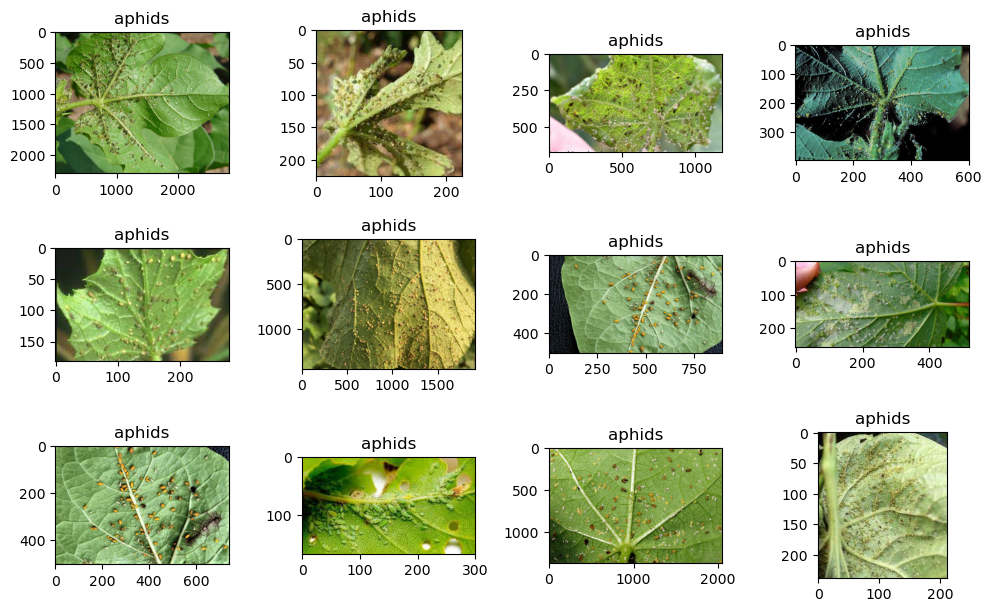

In [6]:
plt.figure(figsize=(10, 8))
for i in range(12):
    plt.subplot(4, 4, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(classes[labels[i]])
plt.tight_layout()

### Shuffle the images

In [7]:
images,labels = shuffle(images,labels)

### Plot some of the image after the shuffle

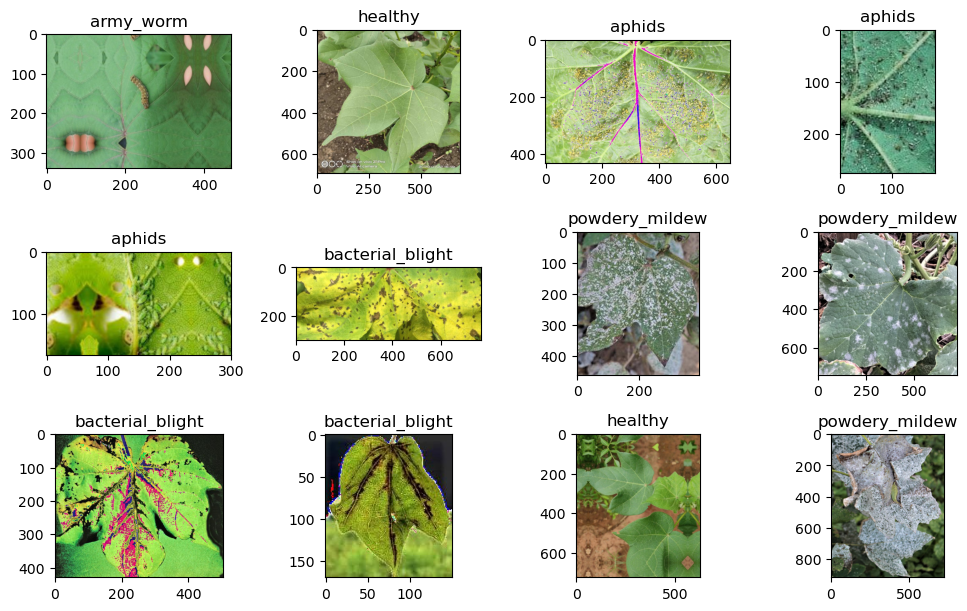

In [8]:
plt.figure(figsize=(10, 8))
for i in range(12):
    plt.subplot(4, 4, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(classes[labels[i]])
plt.tight_layout()

### Resize Images to MobileNetV2 Input Shape (224,224,3)

In [9]:
x = []

for i in images:
    x.append(resize(i, (224,224,3)))

### Plot some of the images after resizing

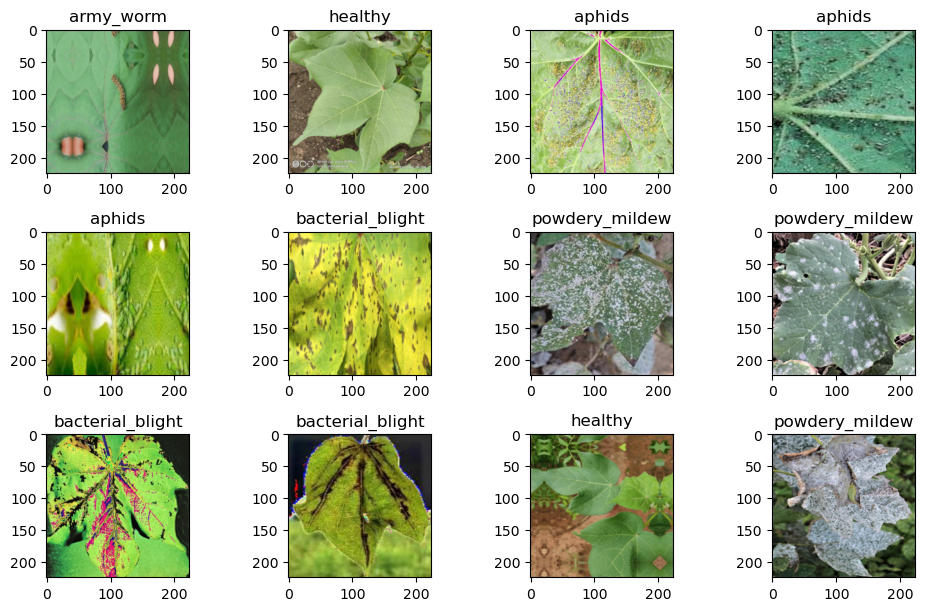

In [10]:
plt.figure(figsize=(10, 8))
for i in range(12):
    plt.subplot(4, 4, i+1)
    plt.imshow(x[i], cmap='gray')
    plt.title(classes[labels[i]])
plt.tight_layout()

### Convert image and label datatypes from list to Numpy array

In [11]:
x = np.array(x)
y = np.array(labels)

### Convert Images and Labels to NumPy Arrays

In [12]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=100)

### MobileNetV2 Pre-trained Feature Extractor Model URL 

In [13]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [14]:
tf.get_logger().setLevel('ERROR')

### Define Number of Output Classes

In [15]:
num_of_classes = 6

### Build Transfer Learning Model using MobileNetV2 Feature Extractor

In [16]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers

In [17]:
base_model = MobileNetV2(
    input_shape = (224,224,3),
    include_top = False,
    weights = 'imagenet'
)
base_model.trainable = False

In [18]:
model = Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation = 'relu'),
    layers.Dropout(0.3),
    layers.Dense(num_of_classes, activation = 'softmax')
])

### Compile Transfer Learning Model

In [19]:
model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

### Train the model

In [20]:
model.fit(x_train,y_train, epochs = 10, batch_size = 32, validation_split = 0.05)

Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 41s 558ms/step - accuracy: 0.7329 - loss: 0.7274 - val_accuracy: 0.8854 - val_loss: 0.4014
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 27s 475ms/step - accuracy: 0.9298 - loss: 0.2155 - val_accuracy: 0.8750 - val_loss: 0.3062
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 27s 471ms/step - accuracy: 0.9618 - loss: 0.1289 - val_accuracy: 0.9062 - val_loss: 0.2398
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 27s 474ms/step - accuracy: 0.9668 - loss: 0.1030 - val_accuracy: 0.9062 - val_loss: 0.2799
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 27s 471ms/step - accuracy: 0.9829 - loss: 0.0696 - val_accuracy: 0.8958 - val_loss: 0.2745
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 30s 518ms/step - accuracy: 0.9912 - loss: 0.0361 - val_accuracy: 0.9271 - val_loss: 0.1928
Epoch 7/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 28s 487ms/step - accuracy: 0.9945 - loss: 0.0298 - val_accuracy: 0.9062 - val_loss: 0.2874
Epoch 8/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 27s 466ms/step - accuracy: 0.9934 - loss: 0.0307 - val_accu

### Model Prediction on Test Data

In [21]:
y_pred = model.predict(x_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 487ms/step


In [22]:
y_pred = [np.argmax(i) for i in y_pred]

### Calculate Accuracy Score

In [23]:
accuracy_score(y_test,y_pred)

0.9600840336134454

### Plot confusion matrix on heatmap

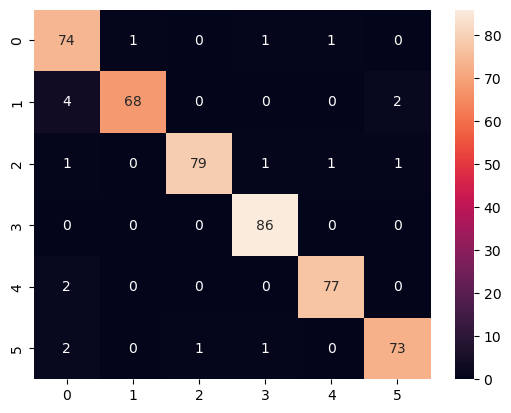

In [24]:
sns.heatmap(confusion_matrix(y_test,y_pred), annot = True, fmt = 'd')
plt.show()

### Print classification report

In [25]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.89      0.96      0.93        77
           1       0.99      0.92      0.95        74
           2       0.99      0.95      0.97        83
           3       0.97      1.00      0.98        86
           4       0.97      0.97      0.97        79
           5       0.96      0.95      0.95        77

    accuracy                           0.96       476
   macro avg       0.96      0.96      0.96       476
weighted avg       0.96      0.96      0.96       476



### Conclusion

In this project, a cotton plant disease detection system was developed using deep learning with a transfer learning approach. A pretrained MobileNetV2 model was used as the base network to extract meaningful visual features from leaf images, improving efficiency and reducing training time compared to training a model from scratch.

The model was customized with additional classification layers to perform disease classification. Image preprocessing was limited to resizing, ensuring consistent input dimensions for the model. Despite minimal preprocessing, the model was able to learn relevant features and achieve effective classification performance.

This project demonstrates the strength of transfer learning and lightweight architectures like MobileNetV2 in solving real-world computer vision problems, while also providing hands-on experience in model fine-tuning and deployment-ready approaches.